# 5장 실습 — 양자화는 행동을 바꾼다

4장의 마지막 표에서 양자화의 출력 오차가 한 자리 퍼센트였다. 작아 보였다.

이 노트북은 그 오차를 **닫힌 고리 안에** 넣는다. 정책은 한 번 부르고 끝나는 함수가 아니라 백 번 넘게 불리면서 매번 로봇을 움직이고, 움직인 결과가 다음 관측이 된다. 그 고리에서 작은 오차가 어떻게 되는지를 잰다.

문헌의 예고가 있다. INT4 양자화가 LIBERO 시뮬에서 0.1~1.5 포인트를 깎았는데 **같은 양자화가 실기 UR5에서는 4 포인트**를 깎았다. 다른 연구는 SmoothQuant W4A8이 LIBERO 평균은 거의 안 건드리면서 실기 집기를 **31/50에서 16/50**으로 무너뜨렸다고 보고한다.

우리는 실기를 못 쓰지만 **닫힌 고리**는 쓸 수 있고, 그것만으로도 정적 지표가 감추는 것이 드러난다.

실행 시간은 CPU에서 5분 안팎이다.

In [1]:
%pip install -q mujoco==3.13.0 koreanize-matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import time
import unicodedata
import numpy as np
import mujoco
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import koreanize_matplotlib  # noqa: F401


def dw(s):
    return sum(2 if unicodedata.east_asian_width(c) in "WF" else 1
               for c in str(s))


def pad(s, n, right=False):
    gap = " " * max(n - dw(s), 0)
    return gap + str(s) if right else str(s) + gap


def wilson(k, n, z=1.96):
    if n == 0:
        return 0., 0.
    ph = k / n
    d = 1 + z * z / n
    c = ph + z * z / (2 * n)
    h = z * ((ph * (1 - ph) + z * z / (4 * n)) / n) ** .5
    return (c - h) / d, (c + h) / d


RED, GREY, INK = "#E32C24", "#8C8A85", "#1C1C1A"
PINK = "#F3A29D"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": .25, "axes.spines.top": False,
                     "axes.spines.right": False})
torch.set_num_threads(2)
print("mujoco", mujoco.__version__, "/ torch", torch.__version__)

mujoco 3.13.0 / torch 2.14.0+cu130


In [3]:
XML = '''
<mujoco model="planar_push">
  <option timestep="0.004" integrator="implicitfast"/>
  <worldbody>
    <geom name="floor" type="plane" size="3 3 .1"
          friction=".6 .005 .0001"/>
    <body name="block" pos="0 0 .031">
      <freejoint/>
      <geom type="cylinder" size=".03 .03" mass=".25"
            friction=".6 .005 .0001"/>
    </body>
    <body name="pusher" pos="0 0 .03">
      <joint name="px" type="slide" axis="1 0 0"/>
      <joint name="py" type="slide" axis="0 1 0"/>
      <geom type="cylinder" size=".012 .03" mass="4"/>
    </body>
  </worldbody>
  <actuator>
    <velocity joint="px" kv="120"/>
    <velocity joint="py" kv="120"/>
  </actuator>
</mujoco>
'''

EP, GOAL_R, AMAX = 110, .03, .35
MODEL = mujoco.MjModel.from_xml_string(XML)


class Vec:
    def __init__(self, n, seed=0, hz=20):
        self.m = MODEL
        self.sub = int(round(1 / hz / self.m.opt.timestep))
        self.n = n
        self.d = [mujoco.MjData(self.m) for _ in range(n)]
        self.g = np.zeros((n, 2))
        self.t = np.zeros(n, int)
        self.db = np.zeros(n)
        self.dp = np.zeros(n)
        self.rng = np.random.default_rng(seed)
        for i in range(n):
            self.reset(i)

    def reset(self, i):
        d = self.d[i]
        mujoco.mj_resetData(self.m, d)
        bx, by = self.rng.uniform(-.03, .03, 2)
        d.qpos[0:2] = [bx, by]
        d.qpos[2] = .031
        d.qpos[7:9] = [bx - .09, by]
        mujoco.mj_forward(self.m, d)
        jit = self.rng.uniform(-.04, .04, 2)
        self.g[i] = np.array([.30, 0.]) + jit
        self.t[i] = 0
        self.db[i] = np.linalg.norm(d.qpos[0:2] - self.g[i])
        self.dp[i] = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])

    def obs(self):
        o = np.empty((self.n, 8), np.float32)
        for i, d in enumerate(self.d):
            b = np.asarray(d.qpos[0:2], float)
            o[i, 0:2] = self.g[i] - b
            o[i, 2:4] = d.qvel[0:2]
            o[i, 4:6] = b - d.qpos[7:9]
            o[i, 6:8] = d.qvel[6:8]
        return o * np.float32(10.)

    def step(self, a):
        r = np.zeros(self.n, np.float32)
        dn = np.zeros(self.n, np.float32)
        sc = []
        for i, d in enumerate(self.d):
            d.ctrl[:] = np.clip(a[i], -1, 1) * AMAX
            for _ in range(self.sub):
                mujoco.mj_step(self.m, d)
            db = np.linalg.norm(d.qpos[0:2] - self.g[i])
            dp = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])
            r[i] = (10 * (self.db[i] - db) + 2 * (self.dp[i] - dp)
                    + (.3 if db < GOAL_R else 0.))
            self.db[i], self.dp[i] = db, dp
            self.t[i] += 1
            if self.t[i] >= EP:
                dn[i] = 1.
                sc.append(float(db < GOAL_R))
                self.reset(i)
        return r, dn, sc

In [4]:
class AC(nn.Module):
    def __init__(self, din=8):
        super().__init__()
        self.pi = nn.Sequential(nn.Linear(din, 64), nn.Tanh(),
                                nn.Linear(64, 64), nn.Tanh(),
                                nn.Linear(64, 2))
        self.v = nn.Sequential(nn.Linear(din, 64), nn.Tanh(),
                               nn.Linear(64, 64), nn.Tanh(),
                               nn.Linear(64, 1))
        self.ls = nn.Parameter(torch.zeros(2) - .5)

    def dist(self, o):
        return torch.distributions.Normal(self.pi(o), self.ls.exp())


def train_rl(budget=250_000, seed=0, n=16, T=32, lr=3e-3):
    torch.manual_seed(seed)
    env = Vec(n, seed)
    ac = AC()
    opt = torch.optim.Adam(ac.parameters(), lr)
    o = env.obs()
    steps = 0
    while steps < budget:
        O = np.empty((T, n, 8), np.float32)
        A = np.empty((T, n, 2), np.float32)
        LP = np.empty((T, n), np.float32)
        R = np.empty((T, n), np.float32)
        V = np.empty((T + 1, n), np.float32)
        D = np.empty((T, n), np.float32)
        for t in range(T):
            ot = torch.from_numpy(o)
            with torch.no_grad():
                di = ac.dist(ot)
                a = di.sample()
                LP[t] = di.log_prob(a).sum(-1).numpy()
                V[t] = ac.v(ot).squeeze(-1).numpy()
            O[t], A[t] = o, a.numpy()
            R[t], D[t], _ = env.step(A[t])
            o = env.obs()
        with torch.no_grad():
            V[T] = ac.v(torch.from_numpy(o)).squeeze(-1).numpy()
        steps += T * n
        adv = np.zeros((T, n), np.float32)
        g = 0.
        for t in reversed(range(T)):
            nt = 1. - D[t]
            dl = R[t] + .99 * V[t + 1] * nt - V[t]
            g = dl + .99 * .95 * nt * g
            adv[t] = g
        rt = adv + V[:T]
        bo = torch.from_numpy(O.reshape(-1, 8))
        ba = torch.from_numpy(A.reshape(-1, 2))
        bl = torch.from_numpy(LP.reshape(-1))
        br = torch.from_numpy(rt.reshape(-1))
        bd = torch.from_numpy(adv.reshape(-1))
        bd = (bd - bd.mean()) / (bd.std() + 1e-8)
        nb = bo.shape[0]
        mb = max(64, nb // 4)
        for _ in range(4):
            idx = torch.randperm(nb)
            for k in range(0, nb, mb):
                j = idx[k:k + mb]
                di = ac.dist(bo[j])
                lp = di.log_prob(ba[j]).sum(-1)
                ratio = (lp - bl[j]).exp()
                l1 = ratio * bd[j]
                l2 = torch.clamp(ratio, .8, 1.2) * bd[j]
                vl = (ac.v(bo[j]).squeeze(-1) - br[j]) ** 2
                loss = (-torch.min(l1, l2).mean() + .5 * vl.mean()
                        - .003 * di.entropy().sum(-1).mean())
                opt.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(ac.parameters(), .5)
                opt.step()
    return ac


t0 = time.time()
POLICY = train_rl()
print(f"정책 학습 끝  ({time.time() - t0:.0f}s)")

정책 학습 끝  (77s)


In [5]:
class Pert(Vec):
    """배포 조건 — 관측 편향, 제어 지연, 다른 마찰"""

    def __init__(self, n, seed=0, bias=(0., 0.), lat=0, mu=.6):
        self.bias = np.asarray(bias)
        self.lat = lat
        super().__init__(n, seed)
        if mu != .6:
            xml = XML.replace('friction=".6', f'friction="{mu}')
            self.m = mujoco.MjModel.from_xml_string(xml)
            self.sub = int(round(1 / 20 / self.m.opt.timestep))
            self.d = [mujoco.MjData(self.m) for _ in range(n)]
            for i in range(n):
                self.reset(i)
        self.buf = [[np.zeros(2)] * (lat + 1) for _ in range(n)]

    def obs(self):
        o = super().obs()
        o[:, 0:2] -= np.float32(self.bias * 10.)
        o[:, 4:6] += np.float32(self.bias * 10.)
        return o

    def step(self, a):
        if self.lat:
            out = np.empty_like(a)
            for i in range(self.n):
                self.buf[i].append(a[i].copy())
                out[i] = self.buf[i][-1 - self.lat]
            a = out
        return super().step(a)


COND = {"명목": dict(),
        "배포": dict(bias=(.006, -.004), lat=1, mu=.80)}
print("평가 조건:", ", ".join(COND))

평가 조건: 명목, 배포


## 비트 수를 손잡이로 만든다

4장은 PyTorch가 주는 INT8 하나만 썼다. 여기서는 **비트 수를 바꿔 가며** 재야 하므로 양자화를 직접 구현한다. 가짜 양자화(fake quantization)라 부르는 방식으로, 값을 정수 격자에 맞춰 반올림한 뒤 다시 실수로 되돌린다. 속도 이득은 없지만 **수치적으로는 진짜 양자화와 같은 오차**를 만든다.

축이 하나 더 있다. 격자를 **텐서 전체에 하나**로 잡을 수도 있고 **출력 채널마다 따로** 잡을 수도 있다. 채널별이 거의 언제나 낫고, 문헌의 방법 대부분이 이 축 위에 있다.

In [6]:
def fq(w, bits, per_channel=True):
    """대칭 가짜 양자화 — 정수 격자에 맞춘 뒤 되돌린다"""
    qmax = 2 ** (bits - 1) - 1
    if per_channel and w.dim() == 2:
        s = w.abs().amax(dim=1, keepdim=True) / qmax
    else:
        s = w.abs().max() / qmax
    s = torch.clamp(s, min=1e-12)
    return torch.clamp(torch.round(w / s), -qmax - 1, qmax) * s


def quantized(net, bits, per_channel=True):
    import copy
    q = copy.deepcopy(net)
    with torch.no_grad():
        for m in q.pi.modules():
            if isinstance(m, nn.Linear):
                m.weight.copy_(fq(m.weight, bits, per_channel))
    return q


BITS = [32, 8, 6, 5, 4, 3]
QNETS = {b: (POLICY if b == 32 else quantized(POLICY, b))
         for b in BITS}
print("만든 정책:", ", ".join(f"{b}비트" for b in BITS))

만든 정책: 32비트, 8비트, 6비트, 5비트, 4비트, 3비트


## 정적 지표는 무엇을 말하는가

먼저 4장과 같은 방식으로 잰다. 같은 관측 묶음에 대해 원본과 양자화판이 내는 **행동의 차이**다.

In [7]:
torch.manual_seed(5)
probe = torch.from_numpy(Vec(512, seed=5).obs())
with torch.no_grad():
    base = POLICY.pi(probe)
print(pad("가중치 비트", 14) + pad("행동 오차", 13, True)
      + pad("상대 오차", 12, True))
STATIC = {}
for b in BITS:
    with torch.no_grad():
        a = QNETS[b].pi(probe)
    e = (a - base).abs().mean().item()
    STATIC[b] = e
    rel = e / base.abs().mean().item() * 100
    print(pad(f"{b}비트", 14) + pad(f"{e:.4f}", 13, True)
          + pad(f"{rel:.2f}%", 12, True))

가중치 비트       행동 오차   상대 오차
32비트               0.0000       0.00%
8비트                0.0008       0.10%
6비트                0.0040       0.49%
5비트                0.0135       1.65%
4비트                0.0607       7.39%
3비트                0.0306       3.73%


In [8]:
def score(net, cond="명목", seed=999, n=150, reps=2):
    torch.manual_seed(seed)
    env = Pert(n, seed, **COND[cond])
    sc = []
    for _ in range(EP * reps):
        o = torch.from_numpy(env.obs())
        with torch.no_grad():
            a = net.dist(o).sample().numpy()
        sc += env.step(a)[2]
    return np.array(sc)


t0 = time.time()
CLOSED = {}
for b in BITS:
    for c in COND:
        CLOSED[(b, c)] = score(QNETS[b], c)
    print(f"{b}비트 끝  ({time.time() - t0:.0f}s)")

print()
print(pad("가중치 비트", 14) + pad("정적 오차", 12, True)
      + pad("명목", 9, True) + pad("배포", 9, True)
      + pad("배포 95% 구간", 18, True))
for b in BITS:
    sc = CLOSED[(b, "배포")]
    lo, hi = wilson(sc.sum(), len(sc))
    print(pad(f"{b}비트", 14)
          + pad(f"{STATIC[b]:.4f}", 12, True)
          + pad(f"{CLOSED[(b, '명목')].mean():.2f}", 9, True)
          + pad(f"{sc.mean():.2f}", 9, True)
          + pad(f"[{lo:.2f}, {hi:.2f}]", 18, True))

32비트 끝  (9s)


8비트 끝  (18s)


6비트 끝  (27s)


5비트 끝  (36s)


4비트 끝  (44s)


3비트 끝  (53s)

가중치 비트      정적 오차     명목     배포     배포 95% 구간
32비트              0.0000     0.92     0.73      [0.67, 0.77]
8비트               0.0008     0.90     0.75      [0.70, 0.80]
6비트               0.0040     0.88     0.76      [0.71, 0.80]
5비트               0.0135     0.76     0.73      [0.67, 0.77]
4비트               0.0607     0.95     0.85      [0.81, 0.89]
3비트               0.0306     0.93     0.24      [0.20, 0.29]


## 세 열이 서로 다른 말을 한다

정적 오차, 명목 성공률, 배포 성공률이 나란히 있다. 셋이 비례하지 않는다.

**명목 조건은 거의 움직이지 않는다.** 3권 3장에서 본 포화다 — 과제가 쉬우면 웬만큼 망가진 정책도 성공하고, 그래서 측정이 아무것도 말해 주지 않는다. 압축을 명목 벤치마크로만 검증하면 이 열만 보게 된다.

**배포 조건에서는 움직인다.** 그리고 이것이 문헌의 구조와 같다. INT4 가 LIBERO 에서 0.1~1.5 포인트인데 실기 UR5 에서 4 포인트였던 것, SmoothQuant 가 LIBERO 평균은 안 건드리면서 실기 집기를 31/50 에서 16/50 으로 무너뜨렸던 것 — 전부 **쉬운 조건이 감춘 것을 어려운 조건이 드러낸** 사례다.

이유는 고리에 있다. 한 스텝의 행동이 조금 달라지면 로봇이 조금 다른 자리로 가고, 그러면 **다음 관측 자체가 달라진다.** 교란이 있으면 그 갈라짐을 되돌릴 여유가 없다.

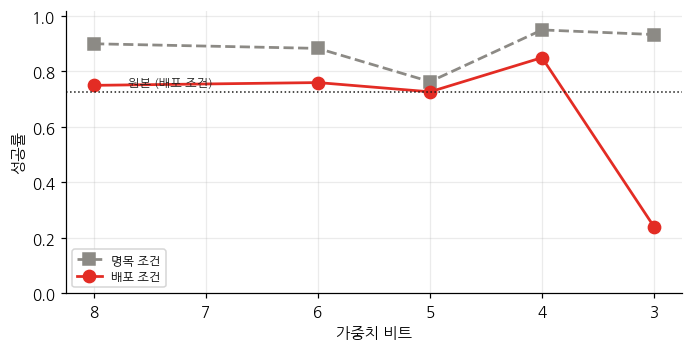

In [9]:
fig, ax = plt.subplots(figsize=(6.4, 3.3))
bb = [b for b in BITS if b != 32]
for c, col, mk in (("명목", GREY, "s--"), ("배포", RED, "o-")):
    ax.plot(bb, [CLOSED[(b, c)].mean() for b in bb], mk,
            color=col, lw=1.8, ms=8, label=f"{c} 조건")
ax.axhline(CLOSED[(32, "배포")].mean(), color=INK, lw=1, ls=":")
ax.text(7.7, CLOSED[(32, "배포")].mean() + .02,
        "원본 (배포 조건)", fontsize=8, color=INK)
ax.set_xlabel("가중치 비트")
ax.set_ylabel("성공률")
ax.set_ylim(0, 1.02)
ax.invert_xaxis()
ax.legend(fontsize=8, loc="lower left")
plt.tight_layout()
plt.show()

## 오차는 지평을 따라 쌓인다

같은 초기 조건에서 원본과 양자화판을 나란히 굴리고, 블록 위치가 얼마나 벌어지는지를 스텝마다 잰다.

In [10]:
def drift(net, seed=31, n=64, steps=90):
    torch.manual_seed(seed)
    ea = Pert(n, seed, **COND["배포"])
    torch.manual_seed(seed)
    eb = Pert(n, seed, **COND["배포"])
    gap = []
    for t in range(steps):
        with torch.no_grad():
            aa = POLICY.pi(torch.from_numpy(ea.obs())).numpy()
            ab = net.pi(torch.from_numpy(eb.obs())).numpy()
        ea.step(aa)
        eb.step(ab)
        pa = np.array([d.qpos[0:2] for d in ea.d])
        pb = np.array([d.qpos[0:2] for d in eb.d])
        gap.append(np.linalg.norm(pa - pb, axis=1).mean() * 1000)
    return np.array(gap)


HS = (1, 10, 30, 60, 90)
print(pad("가중치 비트", 14)
      + "".join(pad(f"{h}스텝", 10, True) for h in HS))
DRIFT = {}
for b in (8, 6, 4, 3):
    g = drift(QNETS[b])
    DRIFT[b] = g
    print(pad(f"{b}비트", 14)
          + "".join(pad(f"{g[h - 1]:.1f}", 10, True) for h in HS))
print()
print("단위는 mm — 원본 정책과 갈라진 블록 위치의 거리")
print(f"성공 판정 반경은 {GOAL_R * 1000:.0f} mm 다")

가중치 비트        1스텝    10스텝    30스텝    60스텝    90스텝


8비트                0.0       4.7      35.9      37.8      37.1


6비트                0.0       3.7      31.5      27.6      26.9


4비트                0.0      15.1      37.9      33.8      32.9


3비트                0.0       7.4     107.9     129.0     130.9

단위는 mm — 원본 정책과 갈라진 블록 위치의 거리
성공 판정 반경은 30 mm 다


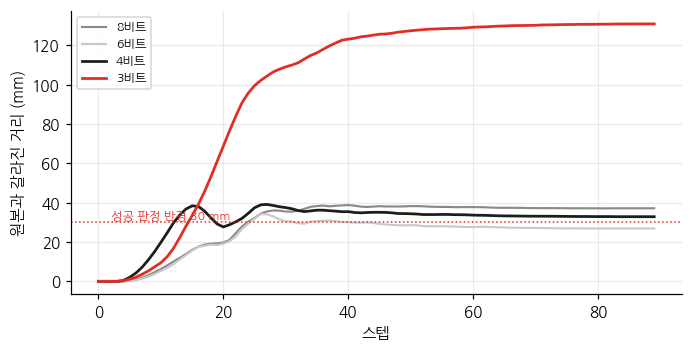

In [11]:
fig, ax = plt.subplots(figsize=(6.4, 3.3))
for b, c in zip((8, 6, 4, 3), (GREY, "#C9C9C9", INK, RED)):
    ax.plot(DRIFT[b], color=c, lw=1.8 if b <= 4 else 1.4,
            label=f"{b}비트")
ax.axhline(GOAL_R * 1000, color=RED, lw=1, ls=":")
ax.text(2, GOAL_R * 1000 + 1.5, "성공 판정 반경 30 mm",
        fontsize=8, color=RED)
ax.set_xlabel("스텝")
ax.set_ylabel("원본과 갈라진 거리 (mm)")
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()

## 실패의 방식도 바뀐다

3권 17장에서 실패에 이름을 붙였다. 같은 분류기를 여기에 붙여 **양자화가 성공률만 깎는지, 아니면 죽는 방식까지 바꾸는지** 본다.

In [12]:
TOUCH, NEAR = .05, .06


def profile(net, seed=77, n=150):
    torch.manual_seed(seed)
    env = Pert(n, seed, **COND["배포"])
    db = [[] for _ in range(n)]
    dp = [[] for _ in range(n)]
    out = []
    for t in range(EP):
        for i in range(n):
            db[i].append(env.db[i])
            dp[i].append(env.dp[i])
        with torch.no_grad():
            ot = torch.from_numpy(env.obs())
            a = net.dist(ot).sample().numpy()
        env.step(a)
    for i in range(n):
        x, y = np.array(db[i]), np.array(dp[i])
        if x[-1] < GOAL_R:
            out.append("성공")
        elif y.min() > TOUCH:
            out.append("F1 도달 실패")
        elif x[-1] > x[0] + .01:
            out.append("F2 방향 오류")
        elif (x < NEAR).sum() > 8:
            out.append("F5 헤맴")
        else:
            out.append("F3 미달")
    return out


KINDS = ["성공", "F1 도달 실패", "F2 방향 오류",
         "F3 미달", "F5 헤맴"]
COLS = [32, 8, 4, 3]
PROF = {b: profile(QNETS[b]) for b in COLS}
print(pad("유형", 16) + "".join(pad(f"{b}비트", 10, True)
                                for b in COLS))
for k in KINDS:
    print(pad(k, 16) + "".join(
        pad(f"{PROF[b].count(k) / len(PROF[b]):.2f}", 10, True)
        for b in COLS))

유형                32비트     8비트     4비트     3비트
성공                  0.79      0.79      0.83      0.29
F1 도달 실패          0.00      0.00      0.00      0.00
F2 방향 오류          0.00      0.00      0.00      0.01
F3 미달               0.13      0.16      0.09      0.63
F5 헤맴               0.07      0.05      0.09      0.07


## 정리

**정적 오차는 닫힌 고리 성적을 예측하지 못한다.** 같은 관측에 대한 행동 차이가 1% 아래여도 닫힌 고리에서는 성적이 움직인다. 관측 자체가 갈라지기 때문이다.

**쉬운 조건은 손상을 감춘다.** 명목 조건의 성공률은 거의 움직이지 않는데 배포 조건에서는 움직인다. 문헌의 시뮬-실기 격차가 바로 이 구조다.

**오차는 지평을 따라 쌓인다.** 한 스텝의 차이는 밀리미터 아래인데, 수십 스텝을 지나면 성공 판정 반경을 넘는다. 비트를 낮출수록 빨리 벌어진다.

**그래서 벤치마크 한 판으로 압축을 검증하면 안 된다.** 문헌의 실기 결과가 시뮬보다 훨씬 나빴던 이유가 여기 있다 — 실기는 고리가 더 길고 더 험하다.

**실패의 방식도 바뀐다.** 성공률 하나로 보면 「조금 나빠졌다」인데, 유형별로 보면 어느 병이 늘었는지가 보인다.

다음 장은 이 표들을 여러 압축 후보에 대해 만들고, **그 순위가 옮겨지는지**를 묻는다.